In [1]:
print("Hi")

Hi


### Exploratory Data Analysis (EDA) with Data Visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df= sns.load_dataset('flights')

In [4]:
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [6]:
df.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [7]:
df.isnull().sum()

year          0
month         0
passengers    0
dtype: int64

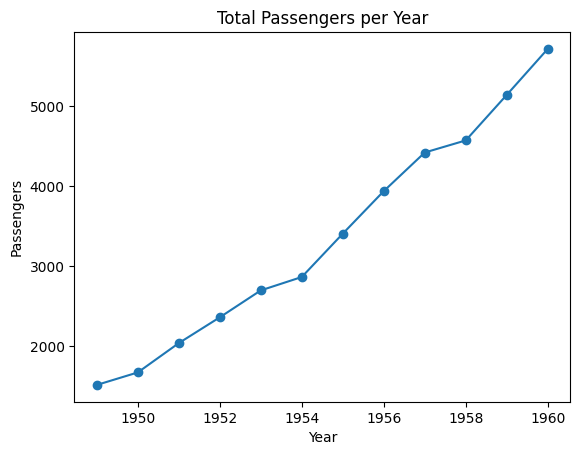

In [12]:
yearly_data= df.groupby("year")["passengers"].sum()
plt.plot(yearly_data.index, yearly_data.values, marker="o")
plt.title("Total Passengers per Year")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

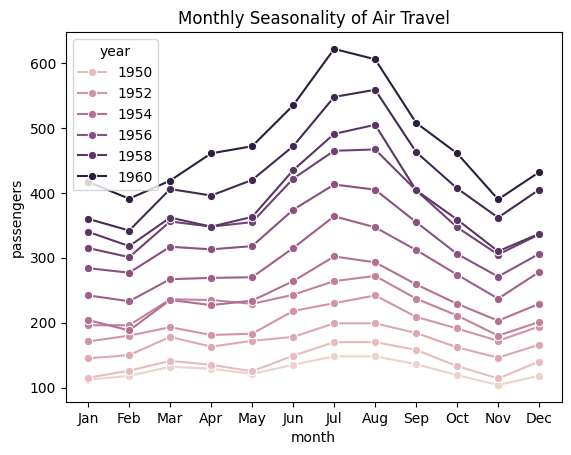

In [13]:
sns.lineplot(x="month", y="passengers", hue="year", data=df, marker="o")
plt.title("Monthly Seasonality of Air Travel")
plt.show()


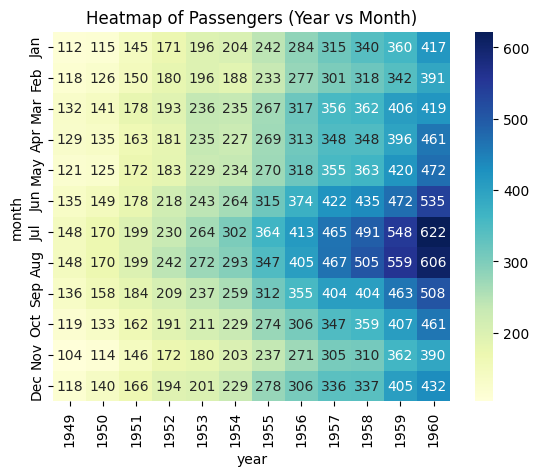

In [16]:
pivot = df.pivot(index="month", columns="year", values="passengers")
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap of Passengers (Year vs Month)")
plt.show()

#### Feature Engineering

Feature Engineering is the process of transforming raw data into meaningful inputs (features) that improve analysis, visualization, or model performance.

    - feature is just a column in dataset

    - Engineering means creating, modifying, or combining columns so the data better represents the underlying problem.


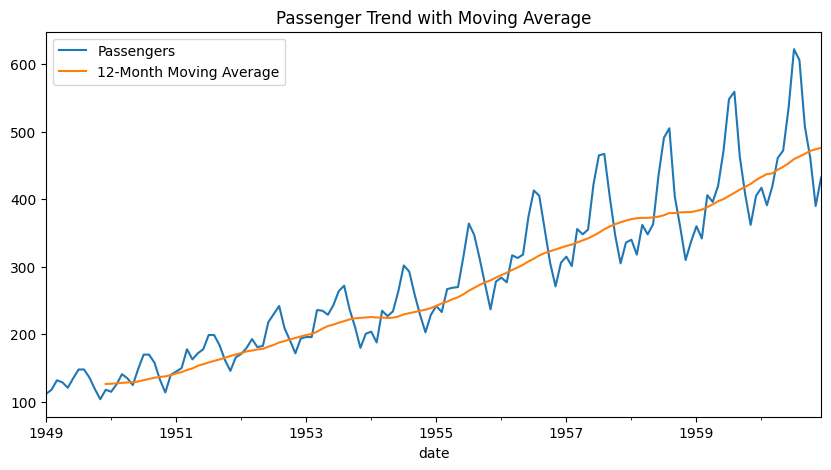

In [18]:
df['date']= pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
df.set_index('date', inplace=True)

df['passengers'].plot(figsize=(10,5), label='Passengers')
df['passengers'].rolling(12).mean().plot(label='12-Month Moving Average')
plt.legend()
plt.title("Passenger Trend with Moving Average")
plt.show()